


# E-Commerce Website A/B Testing — Statistical Analysis

*Author: Prathipa Udayakumar*
***

## Table of Contents

- [Introduction](#intro)
- [Part I - Probability](#probability)
- [Part II - A/B Test](#ab_test)
- [Part III - Regression](#regression)
- [Conclusion](#conclusion)
- [References](#references)


<a id='intro'></a>
## Introduction

A/B tests are very commonly performed by data analysts and data scientists. This project aims to understand the results of an A/B test run on an e-commerce website and to provide the best recommendations to the company to help make decisions on whether they should:
- Implement the new webpage,
- Keep the old webpage, or
- Perhaps run the experiment longer to make their decision.


<a id='probability'></a>
## Part I - Probability

To get started, let's import our libraries.

In [ ]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
import random
import matplotlib.pyplot as plt
%matplotlib inline
random.seed(42)

### 1.1 Data Gathering & Assessing
The dataset is provided in the `ab_data.csv` file. Below is the description of the data, there are a total of 5 columns:



|Data columns|Purpose|Valid values|
| ------------- |:----------| :---|
|user_id|Unique ID|Int64 values|
|timestamp|Time stamp when the user visited the webpage|-|
|group|In the current A/B experiment, the users are categorized into two broad groups. <br>The `control` group users are expected to be served with `old_page`; and `treatment` group users are matched with the `new_page`. <br>However, **some inaccurate rows** are present in the initial data, such as a `control` group user is matched with a `new_page`. |`['control', 'treatment']`|
|landing_page|It denotes whether the user visited the old or new webpage.|`['old_page', 'new_page']`|
|converted|It denotes whether the user decided to pay for the company's product. Here, `1` means yes, the user bought the product.|`[0, 1]`|


**a. Reading the dataset from the `ab_data.csv` file and storing it in a dataframe named `df`.**

In [ ]:
df = pd.read_csv('ab_data.csv')
df.head()

,user_id,timestamp,group,landing_page,converted
0,851104,2017-01-21 22:11:48.556739,control,old_page,0
1,804228,2017-01-12 08:01:45.159739,control,old_page,0
2,661590,2017-01-11 16:55:06.154213,treatment,new_page,0
3,853541,2017-01-08 18:28:03.143765,treatment,new_page,0
4,864975,2017-01-21 01:52:26.210827,control,old_page,1


**b. The number of rows in the dataset.**

In [ ]:
df.shape

(294478, 5)

>The dataset has `294478` total rows and `5` total columns.

**c. The number of unique users in the dataset.**

In [ ]:
df.nunique()

user_id         290584
timestamp       294478
group                2
landing_page         2
converted            2
dtype: int64

>From the `294478` rows in the dataset, only `290584` unique users were recorded.

**d. The proportion of users converted.**

In [ ]:
df['converted'].mean()

0.11965919355605512

>The proportion of users converted were only `12%` (11.96%).

**e. The number of times when the "group" `treatment` do not match with  "landing_page"  `new_page`.**

In [ ]:
#count1 is the no of times treatment group is not shown the new_page
count1 = df.query("group == 'treatment' and landing_page != 'new_page'").count()[0]
#count2 is the no of times control group is not shown the old_page
count2 = df.query("group != 'treatment' and landing_page == 'new_page'").count()[0]
#mismatch is the sum of both mismatched cases of group and landing page
mismatch = count1 + count2
mismatch

3893

**f. Finding if rows have missing values.**

In [ ]:
df.shape

(294478, 5)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 294478 entries, 0 to 294477
Data columns (total 5 columns):
 #   Column        Non-Null Count   Dtype 
---  ------        --------------   ----- 
 0   user_id       294478 non-null  int64 
 1   timestamp     294478 non-null  object
 2   group         294478 non-null  object
 3   landing_page  294478 non-null  object
 4   converted     294478 non-null  int64 
dtypes: int64(2), object(3)
memory usage: 11.2+ MB


>Each column has `294478` non-null entries which is equivalent to the total no of rows in the dataset. There are no rows with missing values.

### 1.2  Data Cleaning - Inaccurate Rows
In a particular row, the **group** and **landing_page** columns should have either of the following acceptable values:

|user_id| timestamp|group|landing_page|converted|
|---|---|---|---|---|
|XXXX|XXXX|`control`| `old_page`|X |
|XXXX|XXXX|`treatment`|`new_page`|X |


It means, the `control` group users should match with `old_page`; and `treatment` group users should matched with the `new_page`.

However, for the rows where `treatment` does not match with `new_page` or `control` does not match with `old_page`, we cannot be sure if such rows truly received the new or old wepage.  


**a. Removing the inaccurate rows, and storing the result in a new dataframe `df2`.**

In [ ]:
df2 = df.drop(df.query("group == 'treatment' & landing_page == 'old_page'").index)
df2 = df2.drop(df.query("group == 'control' & landing_page == 'new_page'").index)
df2.shape

(290585, 5)

In [ ]:
# Double Checking if all of the inaccurate rows were removed from df2 -
# Output 0 confirms that all inaccurate rows were removed successfully.
df2[((df2['group'] == 'treatment') == (df2['landing_page'] == 'new_page')) == False].shape[0]

0

>The new dataframe `df2` now has `290585` rows after removing inaccuracies.

### 1.3  Data Cleaning - Duplicate Rows

**a. Number of unique user_ids in df2**

In [ ]:
df2.user_id.nunique()

290584

>There are `290584` unique **user_ids** in `df2` from `290585` total entries.

**b.There is one user_id repeated in df2.**

In [ ]:
df2[df2.duplicated(subset= 'user_id')].user_id

2893    773192
Name: user_id, dtype: int64

>`773192` is the repeated **user_id** having a duplicate record.

**c. Displaying the rows for the duplicate user_id**

In [ ]:
df2[df2['user_id'] == 773192]

,user_id,timestamp,group,landing_page,converted
1899,773192,2017-01-09 05:37:58.781806,treatment,new_page,0
2893,773192,2017-01-14 02:55:59.590927,treatment,new_page,0


**d. Removing one of the rows with a duplicate user_id, from the df2 dataframe.**

In [ ]:
df2.drop_duplicates(subset= 'user_id', inplace = True)
df2.shape

(290584, 5)

In [ ]:
#checking if duplicates are deleted
df2[df2['user_id'] == 773192]

,user_id,timestamp,group,landing_page,converted
1899,773192,2017-01-09 05:37:58.781806,treatment,new_page,0


> One of the rows with a duplicate **user_id** has been deleted successfully. `df2` now has `290584` rows.

### 1.4  Probability Analysis


**a. Probability of an individual converting regardless of the page they receive<br>**

In [ ]:
p_population = df2['converted'].mean()
p_population

0.11959708724499628

>This probability represents the `overall "converted" success rate` in the population and denoted as $p_{population}$.

**b. Given that an individual was in the `control` group, the probability that they converted is:**

In [ ]:
control = df2[(df2['group'] == 'control')]['converted'].mean()
control

0.1203863045004612

>This probability represents the `conversion rate`, when an individual is in `control group`.

**c. Given that an individual was in the `treatment` group, the probability that they converted is:**

In [ ]:
treatment = df2[(df2['group'] == 'treatment')]['converted'].mean()
treatment

0.11880806551510564

>This probability represents the `conversion rate`, when an individual is in `treatment group`.

**d. Calculating the actual difference between the conversion rates for the two groups:**

In [ ]:
# Calculating the actual difference (obs_diff) between the conversion rates for the two groups.
obs_diff = treatment - control
obs_diff

-0.0015782389853555567

>`obs_diff` gives the **actual difference** between the conversion rates for the two groups.

**e. The probability that an individual received the new page:**

In [ ]:
df2[df2['landing_page'] == 'new_page'].count()[0] / len(df2)

0.5000619442226688

>There is `50%` probability that an individual received the `new page`.

####  Probability Results Observations:

   - The probability that an individual receives the new page is 50% (0.5001)
   - So, there is also a 50% probability that an individial receives the old page.
   - The total probability of an individual converting, irrespective of the page is 11.96% (0.1196)
   - For an individual in contol group, the probability of converting is 12.04% (0.1204)
   - For an individual in treatment group, the probability of converting is 11.88% (0.1188)
   - Based on these statistics, The conversion rate for the old page is slightly higher than the new page. So, there is no significant positive change in conversion rate of new page users to confirm that the treatment group users lead to more conversions than the control group users.

<a id='ab_test'></a>
## Part II - A/B Test

Since a timestamp is associated with each event, we could run a hypothesis test continuously as long as you observe the events.

However, then the hard questions would be:
- Do you stop as soon as one page is considered significantly better than another or does it need to happen consistently for a certain amount of time?  
- How long do you run to render a decision that neither page is better than another?  

These questions are the difficult parts associated with A/B tests in general.  


### 2.1 Setting up Hypothesis
For now, lets consider making a decision just based on all the data provided.  

From the above calculations we found that the conversion rate for the old page is *slightly* higher than that of the new page (1.4.c).

Assuming that old page is better unless new page proves to be definitely better at a Type I error rate of 5%, we can setup the null and alternative hypotheses.

<br>
<center>
$H_0$: $p_{new}$ <= $p_{old}$
</center>
<center>
$H_1$: $p_{new}$ > $p_{old}$
</center><br>
    
    
<center>
$H_0$: $p_{new}$ - $p_{old}$ <= 0
</center>
<center>
$H_1$: $p_{new}$ - $p_{old}$ > 0
</center>

Where,
- $H_0$ is the **Null** Hypothesis
- $H_1$ is the **Alternative** Hypothesis
- $p_{old}$ is the **converted probability** (or conversion rate) for the **old page**
- $p_{new}$ is the **converted probability** (or conversion rate) for the **new page**

### 2.2 Null Hypothesis $H_0$ Testing
Under the null hypothesis $H_0$, we assume that $p_{new}$ and $p_{old}$ are equal. Furthermore, we assume that $p_{new}$ and $p_{old}$ both are equal to the **converted** success rate $p_{population}$ in the `df2` data regardless of the page. So, our assumption is: <br><br>
<center>
$p_{new}$ = $p_{old}$ = $p_{population}$
</center>

>The **conversion rate** for $p_{population}$ in `df2` regardless of page was previously calculated above as `0.11959708724499628` (1.4.a).

**a. The conversion rate for $p_{new}$ under the null hypothesis:**

In [ ]:
p_new = p_population #p_new is the same as p_population under the null
p_new

0.11959708724499628

**b. The conversion rate for $p_{old}$ under the null hypothesis:**

In [ ]:
p_old = p_population #p_old is the same as p_population under the null
p_old

0.11959708724499628

**c. Finding $n_{new}$, the number of individuals in the treatment group:**

In [ ]:
n_new = df2[df2['group'] == 'treatment'].count()[0]
n_new

145310

**d. Finding $n_{old}$, the number of individuals in the control group:**

In [ ]:
n_old = df2[df2['group'] == 'control'].count()[0]
n_old

145274

**e. Simulating Sample for the `treatment` Group**<br>

Simulating $n_{new}$ transactions with a conversion rate of $p_{new}$ under the null hypothesis.  <br>
- The conversion has only 2 outcomes (0,1)
- The individual who has converted is denoted as 1
- the individual who has not converted is denoted as 0
- $p_{new}$ is the probability of new page getting 1 (conversion rate)
- 1 - $p_{new}$ is the probability of new page getting 0 (no conversion rate)
- $p_{old}$ is the probability of old page getting 1 (conversion rate)
- 1 - $p_{old}$ is the probability of old page getting 0 (no conversion rate)

In [ ]:
# Simulating a Sample for the treatment Group
new_page_converted = np.random.choice([0,1], size = n_new, replace = True, p = (1-p_new, p_new))
new_page_converted

array([0, 0, 0, ..., 0, 0, 0])

>`new_page_converted` is the **treatment group sample** that holds $n_{new}$ number of values simulated from the conversion outcomes (0,1) with a conversion rate of $p_{new}$

**f. Simulating Sample for the `control` Group** <br>
Simulating $n_{old}$ transactions with a conversion rate of $p_{old}$ under the null hypothesis.

In [ ]:
# Simulating a Sample for the control Group
old_page_converted = np.random.choice([0,1], size = n_old, replace = True, p = (1-p_old, p_old))
old_page_converted

array([0, 0, 0, ..., 0, 0, 0])

> `old_page_converted` is the **control group sample** that holds $n_{old}$ number of values simulated from the conversion outcomes (0,1) with a conversion rate of $p_{old}$

**g. The difference in the "converted" probability $(p{'}_{new}$ - $p{'}_{old})$ for the simulated samples from the parts (e) and (f) above.**

In [ ]:
new_page_converted.mean() - old_page_converted.mean()

0.00047984011327413534


**h. Sampling distribution** <br>
Re-creating `new_page_converted` and `old_page_converted` to find the $(p{'}_{new}$ - $p{'}_{old})$ value 10,000 times using the same simulation process you used in parts (a) through (g) above, and store the results in `p_diffs`

In [ ]:
# Sampling distribution
p_diffs = []

for _ in range(10000):
    new_page_converted = np.random.choice([0,1], size = n_new, replace = True, p = (1-p_new, p_new))
    old_page_converted = np.random.choice([0,1], size = n_old, replace = True, p = (1-p_old, p_old))
    p_diffs.append(new_page_converted.mean() - old_page_converted.mean())


**i. Histogram**<br>
Plotting a histogram of the **p_diffs**.  

In [ ]:
# convert to numpy
p_diffs = np.array(p_diffs)

Text(0, 0.5, 'Sample Size')

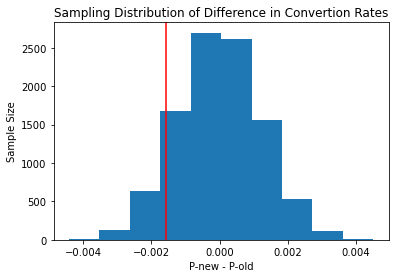

In [ ]:
#Plotting a histogram of the p_diffs
plt.hist(p_diffs);
plt.axvline(x=obs_diff, color='red');
plt.title('Sampling Distribution of Difference in Convertion Rates')
plt.xlabel('P-new - P-old')
plt.ylabel('Sample Size')

>The vertical red line denotes the actual difference `obs_diff` in the `df2`calclulated earlier in (1.4.d).

In [ ]:
obs_diff

-0.0015782389853555567

In [ ]:
# computing p-value
p_val = (p_diffs > obs_diff).mean()
p_val

0.9035

>The proportion of `p_diffs` greater than the actual difference `obs_diff` is `90%`. This is called the **P-value**.

#### Hypothesis Test Results Observations:

**P-value** is the probability of obtaining our observed statistic or a more extreme statistic in favor of the **Alternative hypothesis**, given that we assume **Null hypothesis** is true. So, from the histogram above, including obs_diff (red line), the area on the right of the obs_diff within the bulk of the distribution is the p-value region.

- We know that the **Type I error rate** is 5% (0.05).

- If our **P-value** is <= **Type I error rate**, we can reject the Null.

- If our **P-value** is > **Type I error rate**, we fail to reject the Null.

From the above Hypothesis test results,
**P-value** = `0.90` which is much greater than the **Type I error rate** `0.05`.
Since **P-value** is `90%`, it states that there is `90%` probability of getting the observed difference in conversion rates or a more extreme statistic in favor of the alternative.
Therefore, we fail to reject the Null Hypotheses, which states that conversion rate for old page is better or equal to new page, unless new page proves to be definitely better at a **Type I error rate** of `0.05`.



### 2.3 Built-in Methods for Hypothesis Testing

**j. Using two-sample z-test to achieve similar results**

>**Z-test** is performed when the sample size is large, and the population variance is known. The z-score represents the distance between the two "converted" success rates in terms of the standard error.

In [ ]:
# number of conversions with the old_page
convert_old = df2[df2['landing_page'] == 'old_page']['converted'].sum() #17489

# number of conversions with the new_page
convert_new = df2[df2['landing_page'] == 'new_page']['converted'].sum() #17264

# number of individuals who were shown the old_page
n_old = df2[df2['landing_page'] == 'old_page'].count()[0] #145274

# number of individuals who received new_page
n_new = df2[df2['landing_page'] == 'new_page'].count()[0] #145310
print('convert_old: ',convert_old,'\nconvert_new: ',convert_new,'\nn_old: ',n_old,'\nn_new: ',n_new)

convert_old:  17489 
convert_new:  17264 
n_old:  145274 
n_new:  145310


**k. Now using `sm.stats.proportions_ztest()` to compute your test statistic and p-value.**

The syntax is:
```bash
proportions_ztest(count_array, nobs_array, alternative='larger')
```
where,
- `count_array` = represents the number of "converted" for each group
- `nobs_array` = represents the total number of observations (rows) in each group
- `alternative` = we choose one of the values from `[‘two-sided’, ‘smaller’, ‘larger’]` depending upon two-tailed, left-tailed, or right-tailed respectively.

>Here, our hypothesis is a `right-tailed` test, since we defined $H_1$ as $(p_{new} > p_{old})$. So, the alternative = `larger`.


In [ ]:
#This ztest built-in function will return the z_score, p_value.
count_array = [convert_new, convert_old] #[17264, 17489]
nobs_array = [n_new, n_old] #[145310, 145274]

z_score, p_value = sm.stats.proportions_ztest(count_array, nobs_array, alternative='larger')
print('Z-score: ', z_score, '\nP-value: ', p_value)

Z-score:  -1.3109241984234394 
P-value:  0.9050583127590245


####   Z-test results Observations:
- The p-value obtained from the z test `(0.90)` is similar to the p-value computed earlier using hypothesis test `(0.90)`.
- Hence, we can agree with the findings in hypothesis test results, that we fail to reject the null.
- $Z_{\alpha}$ or $Z_{0.05}$, also known as critical value at 95% confidence interval.  $Z_{0.05}$ is 1.645 for one-tailed tests,  and 1.960 for two-tailed test.
- For our right-tailed test, $Z_{0.05}$ =  `1.645`, we can reject null if $Z_{score}$ > $Z_{\alpha}$
- Based on the z test results, $Z_{score}$ = `-1.3109`
- The  $Z_{score}$ < $Z_{0.05}$, which states that the $Z_{score}$ does not lie in the "rejection region" in the distribution, where the null hypothesis can be rejected.
Therefore, we fail to reject the null.

<a id='regression'></a>
## Part III - A Regression Approach

### 3.1 Fitting Regression Model
In this final part, the result  achieved in the A/B test in Part II above can also be achieved by performing regression.<br><br>

**a. The type of regression to be performed in this case:**

>Since each row in the `df2` data is either a conversion or no conversion, there are only 2 possible outcomes for the response variable. So we should perform  **Logistic Regression** using statsmodels library to fit the regression model and identify if there is a significant difference in conversion based on the page-type a customer receives.

**b.Creating the following two columns in the `df2` dataframe:**
 1. `intercept` - It should be `1` in the entire column.
 2. `ab_page` - It's a dummy variable column, having a value `1` when an individual receives the **treatment**, otherwise `0`.  

In [ ]:
df2['intercept'] = 1
df2[['ab_page','old_page']] = pd.get_dummies(df2['landing_page'])
df2.head()

,user_id,timestamp,group,landing_page,converted,intercept,ab_page,old_page
0,851104,2017-01-21 22:11:48.556739,control,old_page,0,1,0,1
1,804228,2017-01-12 08:01:45.159739,control,old_page,0,1,0,1
2,661590,2017-01-11 16:55:06.154213,treatment,new_page,0,1,1,0
3,853541,2017-01-08 18:28:03.143765,treatment,new_page,0,1,1,0
4,864975,2017-01-21 01:52:26.210827,control,old_page,1,1,0,1


**c. Using statsmodels to instantiate regression model on the 2 columns created above, then fitting the model to predict whether or not an individual converts**

In [ ]:
log_mod = sm.Logit(df2['converted'], df2[['intercept', 'ab_page']])
results1 = log_mod.fit()

Optimization terminated successfully.
         Current function value: 0.366118
         Iterations 6


**d. Summary of the Logistic Regression model:**

In [ ]:
results1.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                           Logit Regression Results                           
==============================================================================
Dep. Variable:              converted   No. Observations:               290584
Model:                          Logit   Df Residuals:                   290582
Method:                           MLE   Df Model:                            1
Date:                Tue, 24 Jan 2023   Pseudo R-squ.:               8.077e-06
Time:                        14:24:55   Log-Likelihood:            -1.0639e+05
converged:                       True   LL-Null:                   -1.0639e+05
Covariance Type:            nonrobust   LLR p-value:                    0.1899
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
intercept     -1.9888      0.008   -246.669      0.000      -2.005      -1.973
ab_page       -0.0150      0.011     -1.311      0.190      -0.037       0.007
==============================================================================
"""

In [ ]:
np.exp(results1.params) #taking exponent of coefficients along with negative sign to interpret regression results

intercept    0.136863
ab_page      0.985123
dtype: float64

In [ ]:
df2.groupby('landing_page').mean()['converted'] #proportion of conversion of each page

landing_page
new_page    0.118808
old_page    0.120386
Name: converted, dtype: float64

**e. The p-value associated with ab_page and how it differs from the value found in Part II:**

#### 1st Regression model Observations:

- The P-Value associated with **ab_page** from the result of the logistic regression model is `0.190`.
- This P-Value (`0.190`) is greater than the Type I error rate (`0.05`), so we fail to reject the null.

- The Null and Alternative hypothesis for logistic regression is:

<center>
$H_0$: $p_{new}$ - $p_{old}$ = 0

    
<center>
$H_1$: $p_{new}$ - $p_{old}$ $\neq$ 0


- So, in Hypothesis test, we performed a right-tailed test, and in Logistic Regression we performed a two-tailed test. This is the reason why the P-values obtained in both the tests from Part II and III are different.

- The **ab_page** coefficient states that conversion is `0.985123` times as likely on new page than on old page, holding all other variables constant (calculated by taking the exponent of the coefficient).


**f. Considering other things that might influence whether or not an individual converts.**

- Apart from the page type that an individual is viewing, there are other factors that might influence whether or not an individual converts, such as the time duration an individual takes to view the page, the country from where the individual is using the page, the loyalty/membership of the individual to the company (regular visitor or new visitor), etc.

- It is a good idea to consider other factors to add into the regression model, because it tells us how statistically significant these independent predictor variables are in impacting the reponse variable.

- However, there are disadvantages to adding additional variables into the regression model because it can create problems in the accuracy of the model. A linear relationship may not exist between the explanatory variable and response variable, there can be multicollinearity where the predictor variables  are correlated with one another, etc.


### 3.2 Adding new variables to regression model

**g. Adding countries**<br>

In [ ]:
df2.head()

,user_id,timestamp,group,landing_page,converted,intercept,ab_page,old_page
0,851104,2017-01-21 22:11:48.556739,control,old_page,0,1,0,1
1,804228,2017-01-12 08:01:45.159739,control,old_page,0,1,0,1
2,661590,2017-01-11 16:55:06.154213,treatment,new_page,0,1,1,0
3,853541,2017-01-08 18:28:03.143765,treatment,new_page,0,1,1,0
4,864975,2017-01-21 01:52:26.210827,control,old_page,1,1,0,1


In [ ]:
# Reading the countries.csv file
df_country = pd.read_csv('countries.csv')
df_country.head()

,user_id,country
0,834778,UK
1,928468,US
2,822059,UK
3,711597,UK
4,710616,UK


In [ ]:
# Joining the  df_country with the df2 dataframe
df_merged = df2.set_index('user_id').join(df_country.set_index('user_id'))
df_merged.head()

,timestamp,group,landing_page,converted,intercept,ab_page,old_page,country
user_id,,,,,,,,
851104,2017-01-21 22:11:48.556739,control,old_page,0,1,0,1,US
804228,2017-01-12 08:01:45.159739,control,old_page,0,1,0,1,US
661590,2017-01-11 16:55:06.154213,treatment,new_page,0,1,1,0,US
853541,2017-01-08 18:28:03.143765,treatment,new_page,0,1,1,0,US
864975,2017-01-21 01:52:26.210827,control,old_page,1,1,0,1,US


In [ ]:
# Creating dummy variables
df_merged[['CA','UK','US']] = pd.get_dummies(df_merged['country'])
df_merged.head()

,timestamp,group,landing_page,converted,intercept,ab_page,old_page,country,CA,UK,US
user_id,,,,,,,,,,,
851104,2017-01-21 22:11:48.556739,control,old_page,0,1,0,1,US,0,0,1
804228,2017-01-12 08:01:45.159739,control,old_page,0,1,0,1,US,0,0,1
661590,2017-01-11 16:55:06.154213,treatment,new_page,0,1,1,0,US,0,0,1
853541,2017-01-08 18:28:03.143765,treatment,new_page,0,1,1,0,US,0,0,1
864975,2017-01-21 01:52:26.210827,control,old_page,1,1,0,1,US,0,0,1


In [ ]:
# Fit model, and summarize the results
log_mod = sm.Logit(df_merged['converted'], df_merged[['intercept', 'ab_page', 'CA', 'UK']])
results2 = log_mod.fit()
results2.summary()

Optimization terminated successfully.
         Current function value: 0.366113
         Iterations 6


<class 'statsmodels.iolib.summary.Summary'>
"""
                           Logit Regression Results                           
==============================================================================
Dep. Variable:              converted   No. Observations:               290584
Model:                          Logit   Df Residuals:                   290580
Method:                           MLE   Df Model:                            3
Date:                Tue, 24 Jan 2023   Pseudo R-squ.:               2.323e-05
Time:                        14:25:59   Log-Likelihood:            -1.0639e+05
converged:                       True   LL-Null:                   -1.0639e+05
Covariance Type:            nonrobust   LLR p-value:                    0.1760
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
intercept     -1.9893      0.009   -223.763      0.000      -2.007      -1.972
ab_page       -0.0149      0.011     -1.307      0.191      -0.037       0.007
CA            -0.0408      0.027     -1.516      0.130      -0.093       0.012
UK             0.0099      0.013      0.743      0.457      -0.016       0.036
==============================================================================
"""

In [ ]:
np.exp(results2.params) #taking exponent of coefficients along with negative sign to interpret regression results

intercept    0.136795
ab_page      0.985168
CA           0.960062
UK           1.009932
dtype: float64

In [ ]:
df_merged.groupby('country').mean()['converted'] #proportion of conversion of each country

country
CA    0.115318
UK    0.120594
US    0.119547
Name: converted, dtype: float64

#### 2nd Regression Model Observations:
- The p-value of all the explanatory variables ab_page, CA, UK are greater than the Type I error rate $\alpha$ (0.05). Fails to reject the null.
- ab_page coefficient states that conversion is `0.985168` times as likely on new page than on old page, holding all other variables constant.
- CA coefficient states that conversion is `0.960062` times as likey in CA than in US (baseline), holding all other variables constant.
- UK coefficient states that conversion is `1.009932` times as likey in UK than in US (baseline), holding all other variables constant.
- Compared to 1st model, ab_page coefficient in 2nd model remains the same and not affected after adding CA and UK variables.
- The countries have no significant impact on conversion rates.

**h. Interaction between page and country**<br>

In [ ]:
# Creating additional columns to show the interactions between page and country.
df_merged["CA_ab_page"] = df_merged["CA"] * df_merged["ab_page"]
df_merged["UK_ab_page"] = df_merged["UK"] * df_merged["ab_page"]
df_merged.head()

,timestamp,group,landing_page,converted,intercept,ab_page,old_page,country,CA,UK,US,CA_ab_page,UK_ab_page
user_id,,,,,,,,,,,,,
851104,2017-01-21 22:11:48.556739,control,old_page,0,1,0,1,US,0,0,1,0,0
804228,2017-01-12 08:01:45.159739,control,old_page,0,1,0,1,US,0,0,1,0,0
661590,2017-01-11 16:55:06.154213,treatment,new_page,0,1,1,0,US,0,0,1,0,0
853541,2017-01-08 18:28:03.143765,treatment,new_page,0,1,1,0,US,0,0,1,0,0
864975,2017-01-21 01:52:26.210827,control,old_page,1,1,0,1,US,0,0,1,0,0


In [ ]:
log_mod = sm.Logit(df_merged['converted'],df_merged[['intercept', 'ab_page', 'CA', 'UK', 'CA_ab_page','UK_ab_page']])
results3 = log_mod.fit()
results3.summary()

Optimization terminated successfully.
         Current function value: 0.366109
         Iterations 6


<class 'statsmodels.iolib.summary.Summary'>
"""
                           Logit Regression Results                           
==============================================================================
Dep. Variable:              converted   No. Observations:               290584
Model:                          Logit   Df Residuals:                   290578
Method:                           MLE   Df Model:                            5
Date:                Tue, 24 Jan 2023   Pseudo R-squ.:               3.482e-05
Time:                        14:26:19   Log-Likelihood:            -1.0639e+05
converged:                       True   LL-Null:                   -1.0639e+05
Covariance Type:            nonrobust   LLR p-value:                    0.1920
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
intercept     -1.9865      0.010   -206.344      0.000      -2.005      -1.968
ab_page       -0.0206      0.014     -1.505      0.132      -0.047       0.006
CA            -0.0175      0.038     -0.465      0.642      -0.091       0.056
UK            -0.0057      0.019     -0.306      0.760      -0.043       0.031
CA_ab_page    -0.0469      0.054     -0.872      0.383      -0.152       0.059
UK_ab_page     0.0314      0.027      1.181      0.238      -0.021       0.084
==============================================================================
"""

In [ ]:
np.exp(results3.params) #taking exponent of coefficients along with negative sign to interpret regression results

intercept     0.137178
ab_page       0.979646
CA            0.982625
UK            0.994272
CA_ab_page    0.954198
UK_ab_page    1.031896
dtype: float64

In [ ]:
df_merged.groupby(['landing_page', 'country']).mean()['converted'] #proportion of conversion for each country in each page

landing_page  country
new_page      CA         0.111902
              UK         0.121171
              US         0.118466
old_page      CA         0.118783
              UK         0.120022
              US         0.120630
Name: converted, dtype: float64

####  3rd Regression model Observations:


- The p-value of all the explanatory variables ab_page, CA, UK, CA_ab_page, UK_ab_page are greater than the Type I error rate $\alpha$ (0.05). Fails to reject the null.
- ab_page coefficient states that conversion is `0.979646` times as likely on new page than on old page, holding all other variables constant.
- CA coefficient states that conversion is `0.982625` times as likey in CA than in US (baseline), holding all other variables constant.
- UK coefficient states that conversion is `0.994272` times as likey in UK than in US (baseline), holding all other variables constant.
- CA_ab_page coefficient states that conversion is `0.954198` times as likely when new page shown in CA than in US (baseline), holding all other variables constant.
- UK_ab_page coefficient states that conversion is `1.031896` times as likely when new page shown in UK than in US (baseline), holding all other variables constant.
- Compared to 1st and 2nd model, ab_page, UK coefficient as slightly decreased, while the CA coefficient slightly increased adding  CA_ab_page, UK_ab_page predictor variables to the model. But these slight changes give statistically insignificant impact on the hypothesis, and there is not strong proof that the interaction between country and page variables influence the coversion rate.

<a id='conclusion'></a>
## Conclusion

- The statistical results from probabilty, Hypothesis tests, Z-tests, Logistic Regression models, had no sufficient evidence to reject the Null hypothesis, which stated that old page is better or similar to the new page in terms of converson rates.
- Therefore, it is recommended to keep the old page because there is no statistically significant evidence to prove that new page has better conversion rate than the old page, so we cannot strongly decide on implementing the new page.
- Perhaps, running the expermiment longer might help the existing users to adapt to the change if they are facing change aversion in the beginning of the experiment.



<a id='references'></a>
## References
- https://www.statsmodels.org/stable/generated/statsmodels.stats.proportion.proportions_ztest.html
- https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.DataFrame.join.html
- https://www.statology.org/null-hypothesis-of-logistic-regression/
